In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding

In [2]:
data = """artificial intelligence systems learn patterns from data.
sequence models process information step by step.
recurrent neural networks are useful for sequence prediction.
lstm networks handle long term dependencies.

deep learning models improve sequence learning.
generative models create new samples from learned patterns.
language models predict the next word in a sentence.
sequence generation is used in chatbots and assistants.

machine learning helps computers learn automatically.
training data improves model accuracy.
neural networks simulate human brain structures.
optimization algorithms improve learning efficiency.

technology is transforming modern education.
online learning platforms use artificial intelligence.
students benefit from intelligent tutoring systems.
automation improves productivity and decision making."""

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([data])

total_words = len(tokenizer.word_index) + 1

In [4]:
input_sequences = []

for line in data.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

In [5]:
max_len = max(len(x) for x in input_sequences)

input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_len, padding='pre')
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(y, num_classes=total_words)

In [6]:
model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(100),
    Dense(total_words, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(X, y, epochs=200, verbose=1)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.0227 - loss: 4.3584   
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0568 - loss: 4.3484    
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0568 - loss: 4.3394
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0568 - loss: 4.3297
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0568 - loss: 4.3160
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0568 - loss: 4.2957
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0568 - loss: 4.2648
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0568 - loss: 4.2138    
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0568 - loss: 4.1425    
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0568 - loss: 4.0943     
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0568 - loss: 4.0795
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - a

In [8]:
def generate_text(seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')

        predicted = np.argmax(model.predict(token_list, verbose=0))

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                seed_text += " " + word
                break
    return seed_text

In [9]:
print(generate_text("artificial intelligence", 8))
print(generate_text("machine learning", 8))

artificial intelligence systems learn patterns from data data data model
machine learning helps computers learn automatically automatically a sentence sentence


In [13]:
from tensorflow.keras.layers import Dense, Embedding, MultiHeadAttention, LayerNormalization, Dropout #transformer component
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

In [14]:
def transformer_block(inputs):
    attention = MultiHeadAttention(num_heads=2, key_dim=32)(inputs, inputs)
    attention = Dropout(0.1)(attention)
    out1 = LayerNormalization(epsilon=1e-6)(inputs + attention)

    ffn = Dense(64, activation='relu')(out1)
    ffn = Dense(inputs.shape[-1])(ffn)

    return LayerNormalization(epsilon=1e-6)(out1 + ffn)

In [15]:
input_layer = Input(shape=(max_len-1,))
x = Embedding(total_words, 64)(input_layer)

x = transformer_block(x)

x = tf.keras.layers.GlobalAveragePooling1D()(x)

output = Dense(total_words, activation='softmax')(x)

transformer_model = Model(input_layer, output)

transformer_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [16]:
transformer_model.fit(X, y, epochs=200)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.0114 - loss: 4.6672
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0227 - loss: 4.2848
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0455 - loss: 4.1068
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0795 - loss: 3.9665
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0909 - loss: 3.8451
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1364 - loss: 3.7213
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1023 - loss: 3.6323
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1705 - loss: 3.5305
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1705 - loss: 3.4423
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1705 - loss: 3.3522
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1932 - loss: 3.2661
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2159 - loss

In [19]:
token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')

predicted = np.argmax(transformer_model.predict(token_list, verbose=0), axis=-1)

In [22]:
def generate_text_transformer(seed_text, next_words=10, temperature=1.0):
    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]


        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')


        preds = transformer_model.predict(token_list, verbose=0)[0]


        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))


        predicted_index = np.random.choice(len(preds), p=preds)


        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                seed_text += " " + word
                break

    return seed_text

In [23]:
print(generate_text_transformer("artificial intelligence", 8))
print(generate_text_transformer("machine learning", 8))

artificial intelligence systems learn patterns from data improves model used
machine learning helps computers learn automatically automatically automatically simulate automatically


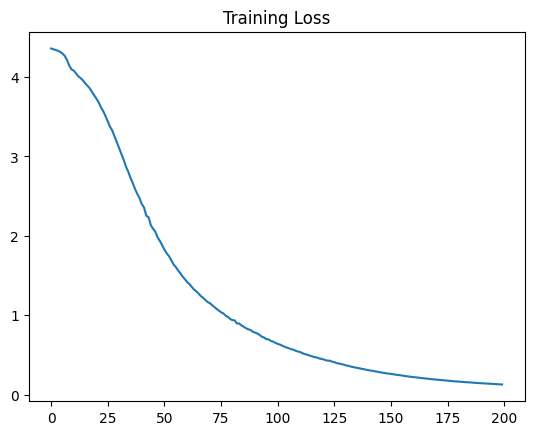

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.show()